# Análise de Dados - Loterias Caixa
<img src='http://loterias.caixa.gov.br/wps/wcm/connect/1bbc9071-30a3-44b7-a1c1-cdcfd57230f5/logo_lotofacil.png?MOD=AJPERES&CACHEID=1bbc9071-30a3-44b7-a1c1-cdcfd57230f5'>

---
#### Adição de bibliotecas, download, extração e leitura do arquivo de dados (Pandas DataFrame).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io
import requests
from zipfile import ZipFile

%matplotlib inline

arq = requests.get('http://www1.caixa.gov.br/loterias/_arquivos/loterias/D_lotfac.zip')   
ZipFile(io.BytesIO(arq.content)).extractall()
dflis = pd.read_html('d_lotfac.htm', thousands='.', decimal=',') # lista de DataFrames
df = dflis[0] # lista[0] contém o primeiro DataFrame
df

,Concurso,Data Sorteio,Bola1,Bola2,Bola3,Bola4,Bola5,Bola6,Bola7,Bola8,Bola9,Bola10,Bola11,Bola12,Bola13,Bola14,Bola15,Arrecadacao_Total,Ganhadores_15_Números,Cidade,UF,Ganhadores_14_Números,Ganhadores_13_Números,Ganhadores_12_Números,Ganhadores_11_Números,Valor_Rateio_15_Números,Valor_Rateio_14_Números,Valor_Rateio_13_Números,Valor_Rateio_12_Números,Valor_Rateio_11_Números,Acumulado_15_Números,Estimativa_Premio,Valor_Acumulado_Especial
0,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,NaN,BA,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
1,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,NaN,PR,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
2,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,NaN,SP,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
3,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,NaN,SP,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
4,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,NaN,SP,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8339,2043,28/09/2020,25,3,15,12,17,9,19,23,7,13,18,22,14,21,5,19195215.0,4,SÃO LUIS,MA,538,19766,182588,787736,223772.11,498.35,25.0,10.0,5.0,0.0,1200000.0,4135663.66
8340,2043,28/09/2020,25,3,15,12,17,9,19,23,7,13,18,22,14,21,5,19195215.0,4,CASCAVEL,PR,538,19766,182588,787736,223772.11,498.35,25.0,10.0,5.0,0.0,1200000.0,4135663.66
8341,2043,28/09/2020,25,3,15,12,17,9,19,23,7,13,18,22,14,21,5,19195215.0,4,JARAGUÁ DO SUL,SC,538,19766,182588,787736,223772.11,498.35,25.0,10.0,5.0,0.0,1200000.0,4135663.66
8342,2044,29/09/2020,17,16,11,3,21,10,5,22,25,20,18,19,13,6,24,15405022.5,0,&nbsp,&nbsp,206,7753,96360,553674,0.00,1736.87,25.0,10.0,5.0,1194490.5,3500000.0,4424653.31


---
### Mostra os nomes das colunas do DataFrame.

In [ ]:
df.columns

Index(['Concurso', 'Data Sorteio', 'Bola1', 'Bola2', 'Bola3', 'Bola4', 'Bola5',
       'Bola6', 'Bola7', 'Bola8', 'Bola9', 'Bola10', 'Bola11', 'Bola12',
       'Bola13', 'Bola14', 'Bola15', 'Arrecadacao_Total',
       'Ganhadores_15_Números', 'Cidade', 'UF', 'Ganhadores_14_Números',
       'Ganhadores_13_Números', 'Ganhadores_12_Números',
       'Ganhadores_11_Números', 'Valor_Rateio_15_Números',
       'Valor_Rateio_14_Números', 'Valor_Rateio_13_Números',
       'Valor_Rateio_12_Números', 'Valor_Rateio_11_Números',
       'Acumulado_15_Números', 'Estimativa_Premio',
       'Valor_Acumulado_Especial'],
      dtype='object')

---
### Remove as colunas 'Cidade' e 'UF' e as linhas repetidas.


In [ ]:
dfsr = df.drop(columns=['Cidade', 'UF']) # remove as colunas que não se repetem
dfsr.drop_duplicates(inplace=True) # remove as linhas repetidas
dfsr.reset_index(drop=True, inplace=True) # reinicia os índices da tabela
dfsr

,Concurso,Data Sorteio,Bola1,Bola2,Bola3,Bola4,Bola5,Bola6,Bola7,Bola8,Bola9,Bola10,Bola11,Bola12,Bola13,Bola14,Bola15,Arrecadacao_Total,Ganhadores_15_Números,Ganhadores_14_Números,Ganhadores_13_Números,Ganhadores_12_Números,Ganhadores_11_Números,Valor_Rateio_15_Números,Valor_Rateio_14_Números,Valor_Rateio_13_Números,Valor_Rateio_12_Números,Valor_Rateio_11_Números,Acumulado_15_Números,Estimativa_Premio,Valor_Acumulado_Especial
0,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
1,2,06/10/2003,23,15,5,4,12,16,20,6,11,19,24,1,9,13,7,0.0,1,184,6232,81252,478188,596323.70,1388.95,10.0,4.0,2.0,0.0,0.0,0.00
2,3,13/10/2003,20,23,12,8,6,1,7,11,14,4,16,10,9,17,24,0.0,2,158,6897,96244,608211,400623.70,2173.36,10.0,4.0,2.0,0.0,0.0,0.00
3,4,20/10/2003,16,5,25,24,23,8,12,2,17,18,1,10,4,19,13,0.0,1,258,9569,123912,706657,902226.02,1498.72,10.0,4.0,2.0,0.0,0.0,0.00
4,5,27/10/2003,15,13,20,2,11,24,9,16,4,23,25,12,8,19,1,0.0,2,472,14736,195636,860992,380017.55,687.49,10.0,4.0,2.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2040,2041,25/09/2020,14,24,25,4,23,13,17,1,2,19,9,7,11,16,22,19965760.0,4,749,15475,156669,751053,319676.47,511.37,25.0,10.0,5.0,0.0,1200000.0,3679631.88
2041,2042,26/09/2020,24,15,14,10,22,8,4,25,2,21,17,18,9,3,12,13845880.0,1,261,8449,95737,510570,989842.89,1136.00,25.0,10.0,5.0,0.0,1500000.0,3919110.01
2042,2043,28/09/2020,25,3,15,12,17,9,19,23,7,13,18,22,14,21,5,19195215.0,4,538,19766,182588,787736,223772.11,498.35,25.0,10.0,5.0,0.0,1200000.0,4135663.66
2043,2044,29/09/2020,17,16,11,3,21,10,5,22,25,20,18,19,13,6,24,15405022.5,0,206,7753,96360,553674,0.00,1736.87,25.0,10.0,5.0,1194490.5,3500000.0,4424653.31


---
### Seleciona apenas as colunas dos números sorteados de cada concurso e calcula a qtde de vezes que cada número foi sorteado. Mostra também os números menos e mais sorteados.
<ul>
<li>Na primeira linha, dfsr.iloc[:, 2:17] também pode ser usado.
</ul>


In [ ]:
dfbolas = dfsr.loc[:, 'Bola1':'Bola15'].to_numpy()
qtde_sor = np.array([[n, (dfbolas == n).sum()] for n in range(1, 26)]) # números e qtdes sorteadas (ou numpy.count_nonzero(df == x))

mi, ma = min(qtde_sor[:, 1]), max(qtde_sor[:, 1])
lmi = qtde_sor[:, 0][(qtde_sor[:, 1] == mi)] # seleciona os números que têm a mesma qtde de mi (qtde mínima).
lma = qtde_sor[:, 0][(qtde_sor[:, 1] == ma)] # o mesmo para a qtde máxima.
print(f'\nMínimo = {mi} {lmi}\nMáximo = {ma} {lma}')


Mínimo = 1165 [8]
Máximo = 1266 [13]


---
### Gráfico de barras que mostra a qtde sorteada de cada número (ORDEM CRESCENTE). Destaque para os 15 mais sorteados.

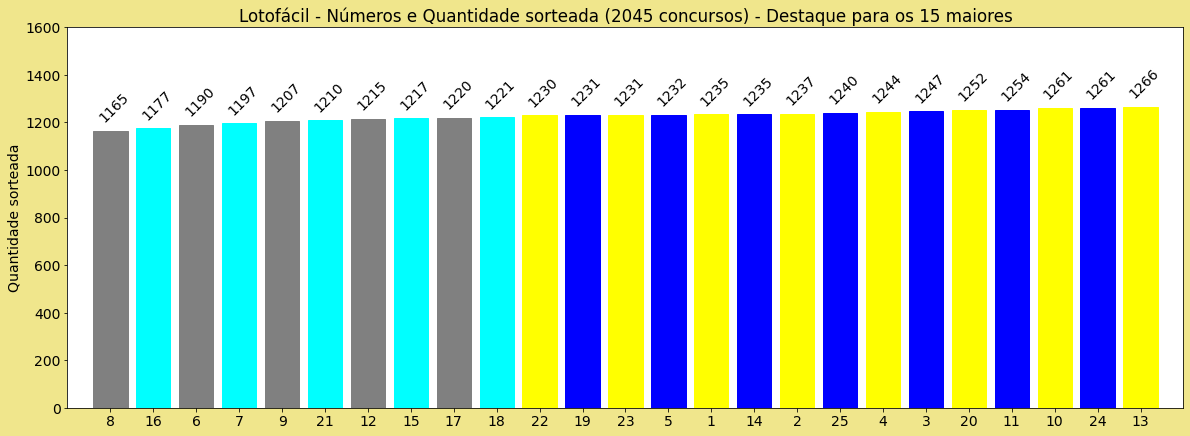

In [ ]:
qtde_sor_ord = np.array(sorted(qtde_sor, key=lambda x: x[1])) # ordena os números de acordo com a qtde de sorteios

plt.rcParams['figure.figsize'] = (20, 7) # tamanho da imagem
plt.rcParams['figure.facecolor'] = 'khaki'
plt.rcParams['font.size'] = 14 # tamanho da fonte dos textos
plt.axis([0, 26, 0, 1600]) # intervalo dos eixos x e y

# gráfico de barras horiz. X e Y são listas
barras = plt.bar(range(1, 26), qtde_sor_ord[:, 1], tick_label=qtde_sor_ord[:, 0])

plt.title(f'Lotofácil - Números e Quantidade sorteada ({dfsr.shape[0]} concursos) - Destaque para os 15 maiores') # shape contém qtde de linhas e colunas (tuple)
plt.ylabel('Quantidade sorteada')
for i in range(25):
    cor1, cor2 = 'gray', 'cyan'
    if i >= 10: # cor diferente para os 15 valores com mais frequência nos sorteios
        cor1, cor2 = 'yellow', 'blue'
    barras[i].set_color(cor1 if i % 2 == 0 else cor2)
for i, bar in enumerate(barras):
    plt.text(bar.get_x() + bar.get_width() + 0.1, 1.02 * bar.get_height(), qtde_sor_ord[i, 1],
             ha='right', va='bottom', rotation=45)
plt.show()

---
### Gráfico de 'torta' que mostra a qtde e a porcentagem de prêmios distribuídos por estado (UF).

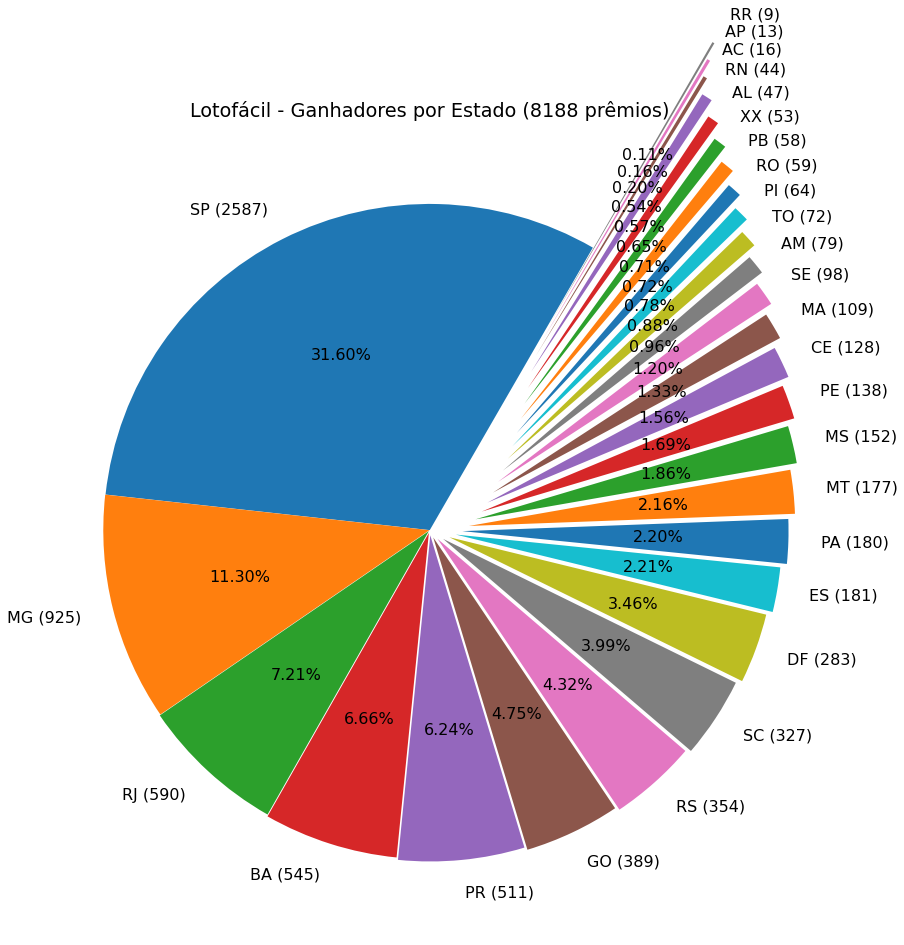

In [ ]:
dfuf = df[df['UF'] != '&nbsp']
dfuf_vc = dfuf['UF'].value_counts()
plt.rcParams['figure.figsize'] = (15, 15) # tamanho da imagem
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 16 # tamanho da fonte dos textos
plt.pie(dfuf_vc, [x ** 2 * 0.001 for x in range(len(dfuf_vc))], 
        [dfuf_vc.index[i] + ' (' + str(val) + ')' for i, val in enumerate(dfuf_vc)], 
        autopct='%.2f%%', startangle=60)
plt.title(f'Lotofácil - Ganhadores por Estado ({sum(dfuf_vc)} prêmios)') 
plt.show()